# **Problem Statement:**
**Banks want to detect fraudulent credit card transactions.**
| Transaction                          | Amount | Result |
| ------------------------------------ | ------ | ------ |
| Grocery purchase                     | ₹2000  | Normal |
| Flight ticket                        | ₹15000 | Normal |
| Random purchase from another country | ₹98000 | Fraud  |

The ML model must answer:
Is this transaction fraud or not?

**Why this problem is difficult?**

Fraud transactions are very rare.

Total transactions = 284,807

Fraud transactions = 492

That means =
**Fraud percentage = 0.172%**

So if a model predicts: Everything = normal

**Accuracy becomes: 99.82%**
, But the model is completely useless.

This teaches the first ML lesson:
**Accuracy is not always a good metric.**

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The Kaggle dataset 'mlg-ulb/creditcardfraud' typically contains a file named 'creditcard.csv'
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_171/2128964430.py:11: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

What These Columns Mean

Important concept.

V1–V28

**These are PCA transformed features.**

Meaning:

The bank hid real transaction information for privacy.

So they transformed them using Principal Component Analysis.

You don’t need to understand PCA deeply right now.

Just know: **V1–V28 = anonymized transaction features**

In [ ]:
df.shape

(284807, 31)

In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


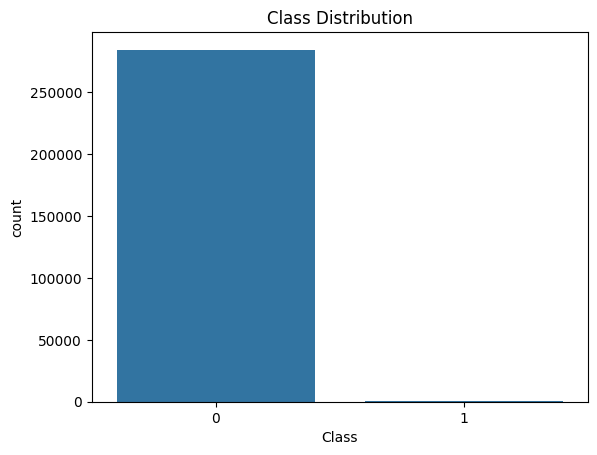

In [ ]:
# this is extremely imbalanced data, let's visualize it.
sns.countplot(x='Class', data=df)
plt.title('Class Distribution')
plt.show()

# **Great. Now we move to Phase 2 — Exploratory Data Analysis (EDA) 🕵️‍♂️**

This is where real ML thinking starts. Most beginners rush to training models, but good engineers spend a lot of time understanding the data first.

**Why EDA is Important?**

Imagine you are a fraud investigator at a bank.

Before building a detection system, you would ask questions like:

Do fraud transactions happen at specific times?

Are fraud transactions usually high value?

Do certain features behave differently for fraud?

**EDA helps us discover patterns before training models.**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]
print("Fraud Cases : {}".format(len(fraud)))
print("Normal Cases : {}".format(len(normal)))

Fraud Cases : 492
Normal Cases : 284315


In [ ]:
# lets get fraud percentage
fraud_percentage = round((len(fraud)/len(df)) *100,3)
print(f"Fraud Percentage : {fraud_percentage}%")

Fraud Percentage : 0.173%


In [ ]:
# Important insight
# Fraud detection is a rare event detection problem.
# This type of ML problem appears in:
# 1)fraud detection
# 2)cybersecurity intrusion detection
# 3)medical disease detection
# 4)manufacturing defect detection

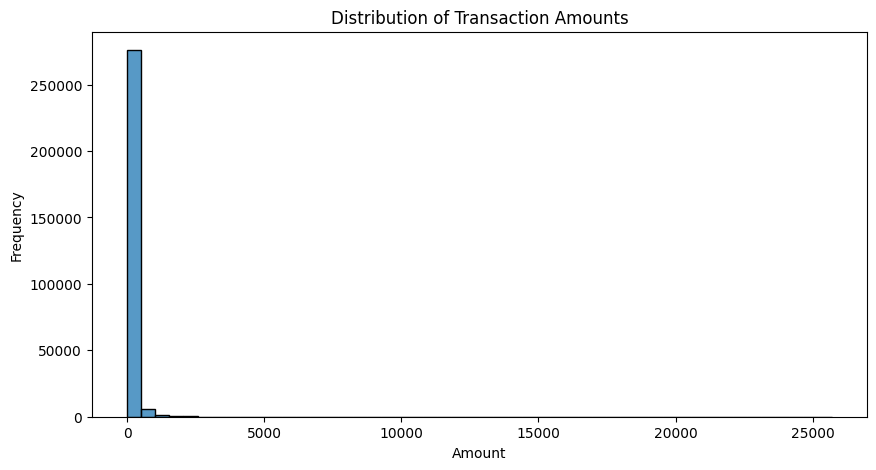

In [ ]:
# now we will analyse transaction amounts.
plt.figure(figsize=(10,5))
sns.histplot(df['Amount'], bins=50)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

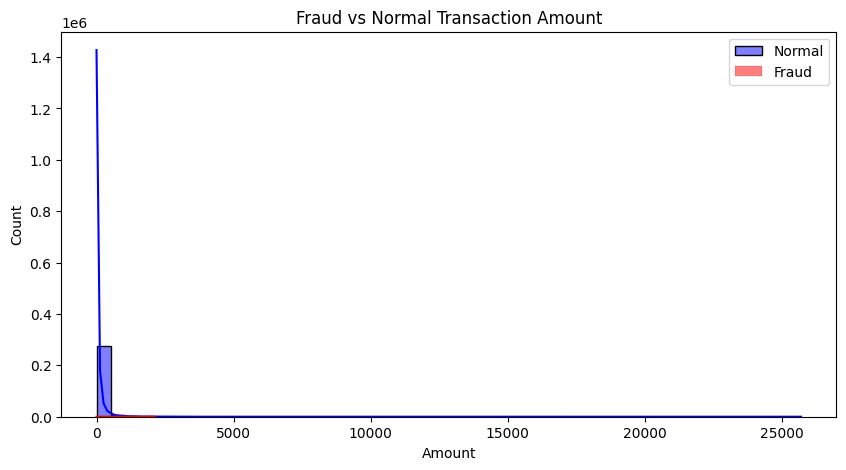

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(normal['Amount'], bins=50, color='blue', label='Normal', kde=True)
sns.histplot(fraud['Amount'], bins=50, color='red', label='Fraud', kde=True)

plt.legend()
plt.title("Fraud vs Normal Transaction Amount")
plt.show()

Interpretation

We wanted to see:

**Do fraud transactions have different amount patterns?**

Sometimes fraud transactions cluster around medium values, not very high values.

Why?

Because fraudsters try to avoid detection.

**Now analyze the time feature.**

What "Time" means

**Time represents seconds since the first transaction in the dataset.**

| Time | Meaning           |
| ---- | ----------------- |
| 0    | first transaction |
| 3600 | 1 hour later      |
| 7200 | 2 hours later     |


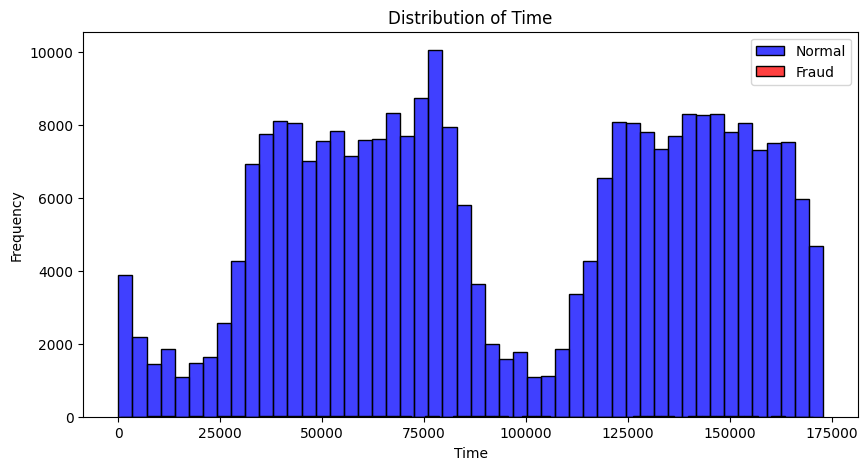

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(normal['Time'], bins=50, color='blue', label='Normal')
sns.histplot(fraud['Time'], bins=50, color='red', label='Fraud')
plt.legend()
plt.title('Distribution of Time')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.show()

Investigation question

Do frauds occur late at night more often?

Sometimes they do.

Why?

Because: Fewer people actively monitoring systems

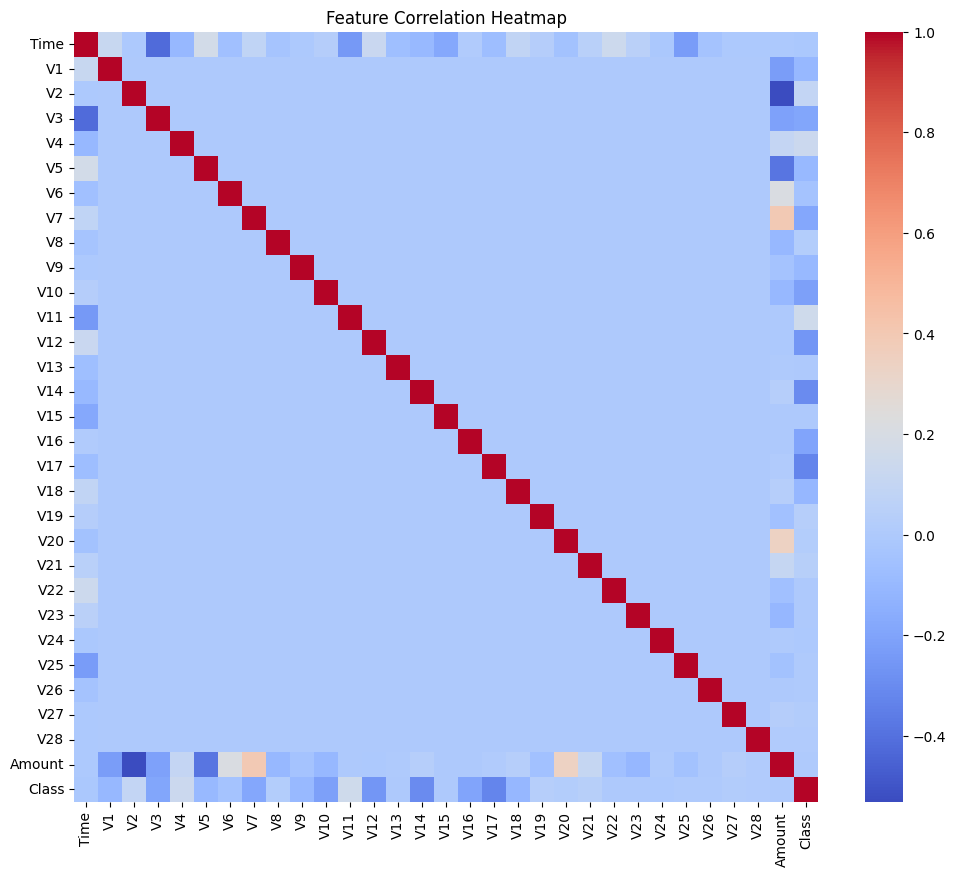

In [ ]:
plt.figure(figsize=(12,10))
corr = df.corr()

sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# from above we can see that columns v7 and v20 are positively correlated with amount.
# and some columns show staron negative correlation with the class.

# **Lesson 3 — Why Accuracy is Dangerous in Fraud Detection**

Most beginners judge models using accuracy.

**But in fraud detection, accuracy can completely lie to you.**

Let's understand why.

Imagine This Scenario:
Suppose a bank processes 100,000 transactions.

**Fraud = 100 Normal = 99,900**

Now imagine a very lazy ML model that predicts:
Everything = Normal

| Prediction | Result         |
| ---------- | -------------- |
| Normal     | Correct        |
| Normal     | Correct        |
| Normal     | Correct        |
| Normal     | Correct        |
| Normal     | Actually fraud |

Accuracy Calculation Formula:

**Accuracy = Correct Predictions / Total Predictions**

So here:

**Correct = 99,900 Total = 100,000**

**Accuracy = 99.9%**

That looks amazing.

But the model detected ZERO frauds.

So the bank loses money.

This is why accuracy fails for imbalanced datasets.

# **The Confusion Matrix**

To understand model behavior we use a confusion matrix. It looks like this =

|               | Predicted Normal | Predicted Fraud |
| ------------- | ---------------- | --------------- |
| Actual Normal | True Negative    | False Positive  |
| Actual Fraud  | False Negative   | True Positive   |

1) **True Positive (TP)** = Model predicts fraud and it is actually fraud.

Transaction flagged as fraud → actually fraud.

2) **True Negative (TN)** = Model predicts normal and it is normal.

Transaction allowed → normal purchase.

3) **False Positive (FP)** = Model predicts fraud but it is normal.

Customer buying groceries → blocked by bank.

4) **False Negative (FN)** = Model predicts normal but it is fraud.

Fraud transaction → bank allows it.

This is very dangerous.

# **Precision, Recall, F-1 Score**

1) **Precision** = Of all predicted frauds,
how many were actually fraud?

**Precision = TP / (TP + FP)**

2) **Recall** = Of all actual frauds,
how many did the model detect?

**Recall = TP / (TP + FN)**

3) **F-1 Score** = F1 score balances precision and recall.

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

This gives balanced model performance.

In [ ]:
# lets simulate a model. here we will create a simple baseline model.
# this model will intentionally perform badly so we can see the metrics behavior.

from sklearn.dummy import DummyClassifier

# what is dummy classifier?
# this is a model that makes random or naive predictions. we use it as baseline.

In [ ]:
x = df.drop('Class', axis=1)
y = df['Class']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state = 42
)

In [ ]:
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)

DummyClassifier(strategy='most_frequent')

In [ ]:
#make predictions
y_pred = dummy.predict(x_test)

In [ ]:
# Evaluate model
print(confusion_matrix(y_test, y_pred))

[[56864     0]
 [   98     0]]


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.00      0.00      0.00        98

    accuracy                           1.00     56962
   macro avg       0.50      0.50      0.50     56962
weighted avg       1.00      1.00      1.00     56962



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# **What You Will Observe?**

Accuracy will be extremely high.

But recall for fraud will be: 0

**meaning : Model detected ZERO frauds**

**This demonstrates why accuracy is misleading.**

# **Lesson 4 — Handling Imbalanced Data**

Your dataset currently looks like this:

| Class  | Count    |
| ------ | -------- |
| Normal | ~284,315 |
| Fraud  | ~492     |

Visualizing it:

Normal transactions  █████████████████████████████████████████████████████

Fraud transactions   █

The model sees thousands of normal transactions for every fraud. So it learns:

**"Just predict everything as normal." Because that gives high accuracy.**

**Why This Happens (Concept)?**

Machine learning models try to minimize error.

Since fraud is extremely rare, the model thinks:
Predicting normal most of the time = lowest error
This is why our DummyClassifier detected zero fraud.

# **Strategies to handle Imbalanced Data :**

There are three main approaches.

| Method              | Idea                    |
| ------------------- | ----------------------- |
| Oversampling        | Increase minority class |
| Undersampling       | Reduce majority class   |
| Algorithmic methods | Change model behavior   |


We will explore **two important techniques.**

# Technique 1 — Undersampling :

**Idea: Reduce normal transactions so dataset becomes balanced.**

| Class  | Count |
| ------ | ----- |
| Normal | 492   |
| Fraud  | 492   |

So instead of: 284,807 rows

We get : 984 rows

Pros :

1) Faster training.

2) Balanced dataset.

Cons :

1) Lose a lot of information.

2) May remove useful patterns.

# Technique 2 — SMOTE (Synthetic Minority Oversampling Technique) :

SMOTE is one of the most famous techniques for imbalanced datasets.

**Idea : Instead of copying fraud samples, it creates synthetic ones.**

Example , Suppose fraud transactions look like this:
| V1 | V2 |
| -- | -- |
| 2  | 5  |
| 3  | 6  |

SMOTE creates a synthetic point between them:

| V1  | V2  |
| --- | --- |
| 2.5 | 5.5 |

**Visualization**

Without SMOTE:


Fraud      • •

Normal     • • • • • • • • • • • •

With SMOTE:

Fraud      • • • • • • • •

Normal     • • • • • • • • • • • •

**Dataset becomes more balanced.**

# **Important Rule (Very Important) :**

**SMOTE must ONLY be applied on training data.**

Never on test data.

Why?

Because the test set should represent real-world distribution.



In [ ]:
# lets import SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [ ]:
print(y_train.value_counts())

Class
0    227451
1       394
Name: count, dtype: int64


In [ ]:
print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


look how it balanced the dataset.

In the next step : we will build three types of models.

**Model 1 — Logistic Regression (Baseline)**

This will teach:

1) linear models

2) probability outputs

3) threshold decisions

**Model 2 — Isolation Forest**

This introduces anomaly detection.

Idea : Fraud transactions behave differently from normal ones.

**Model 3 — Autoencoder (Deep Learning)**

This introduces neural networks for anomaly detection.

The model learns normal transaction patterns and flags unusual ones.

# **Concept — What is Logistic Regression?**

Despite the name, Logistic Regression is a classification algorithm, not regression.

It predicts probability of a class.

Example : Transaction → Fraud probability = 0.82

then we apply threshold if , probability > 0.5

Prediction : Fraud

else : Normal

Why is it called Logistic?

**Because it uses Logistic function** (sigmoid)

Formula = **1 / (1 + e^-x)**

This converts any value into a number between 0 and 1.

| Input | Output |
| ----- | ------ |
| -5    | 0.006  |
| 0     | 0.5    |
| 5     | 0.993  |

This becomes probability of fraud.

**Logistic Regression Pipeline :**

Features → Logistic Regression → Probability → Threshold → Prediction

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
# create model
model = LogisticRegression(max_iter=1000)

In [ ]:
# train the model
model.fit(x_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
# as we got above warning lets use StandardScalar
# as the above warning means model was not able to learn the optimal weights.

The Real Reason in Your Dataset

Your dataset contains features with very different scales.

| Feature | Range      |
| ------- | ---------- |
| V1      | -2 to 2    |
| V5      | -10 to 10  |
| Amount  | 0 to 25000 |

Machine learning algorithms perform better when features are scaled similarly.

**Without Scaling =**
**optimization becomes slow**

for scaling we use python library called **StandardScaler.**

It transforms the data so that,

**mean = 0 &**
**standard deviation = 1**

**Formula = z = (x − mean) / std**

Example :
| Original | Scaled |
| -------- | ------ |
| 500      | 0.12   |
| 2000     | 0.45   |
| 10000    | 1.7    |


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_trained_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

**Important ML Concept**

fit_transform() → learn scaling parameters

transform() → apply learned scaling

**We never fit on test data.**

Why?

Because test data must simulate real unseen data.

In [ ]:
# now apply SMOTE again
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_trained_scaled, y_train)

In [ ]:
print(x_train_smote.shape)
print(y_train_smote.shape)

(454902, 30)
(454902,)


In [ ]:
# train logistic model again
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=2000)
model.fit(x_train_smote,y_train_smote)

LogisticRegression(max_iter=2000)

In [ ]:
y_pred = model.predict(x_test_scaled)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[55424  1440]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



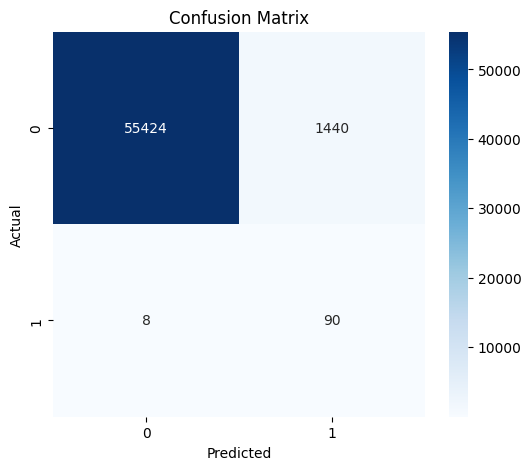

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
print(x_train.shape)
print(x_trained_scaled.shape)
print(x_train_smote.shape)

(227845, 30)
(227845, 30)
(454902, 30)


**What the Dataset Looked Like Before SMOTE**

Training data distribution looked something like this:
| Class  | Count    |
| ------ | -------- |
| Normal | ~227,450 |
| Fraud  | ~395     |

Very imbalanced.

Visualisation :

Normal███████████████████

Fraud █

**What SMOTE did?**

SMOTE balanced the dataset by generating synthetic fraud examples.

After SMOTE

| Class  | Count   |
| ------ | ------- |
| Normal | 227,451 |
| Fraud  | 227,451 |

hence total rows became =

**227451 + 227451 = 454902**

In [ ]:
# now we move to one of the most interesting ideas in machine learning.
#until now we used supervised learning, now we will explore Anomaly detection.
# this is actually very close to how real fraud system works.

# **Isolation Forest (Anomaly Detection)**

anomaly detection means find the observations that behave very differently from the majority.

Example of anomalies

| Domain        | Anomaly           |
| ------------- | ----------------- |
| Banking       | Fraud transaction |
| Cybersecurity | Hacker activity   |
| Healthcare    | Rare disease      |
| Manufacturing | Defective product |

These are all rare events.

**Intuition behind Isolation forest =**

Fraud data behaves very differently.

example = normal transaction: $200, $700

fraud transaction: $95000

**This transaction is far from cluster.**

key idea of isolation forest =
Isolate unusual data points.

**why is it called Isolation Forest?**

The algorithm builds many random decision trees, where each tree splits data randomly.

Fraud points usually get isolated in fewer splits.

Normal points require many splits.

**Key Insight =**

Fraud transactions have shorter path lengths in trees.because they get isolated very quickly.

**When Isolation forest is useful?**

it works well when,

1) Fraud examples are rare

2) Data has unusual patterns

This is why it is used in ,

1) fraud detection

2) network intrusion detection

3) credit risk analysis

In [ ]:
from sklearn.ensemble import IsolationForest

In [ ]:
# create model
iso_model = IsolationForest(
    n_estimators=100,
    contamination=0.00017,
    random_state=42
)

In [ ]:
iso_model.fit(x_trained_scaled)

IsolationForest(contamination=0.00017, random_state=42)

In [ ]:
# notice no y_train, as it is unsupervised
iso_pred = iso_model.predict(x_test_scaled)

but isolation forest returns,
| Output | Meaning |
| ------ | ------- |
| 1      | Normal  |
| -1     | Anomaly |

this (1, -1) must be converted to (1,0)

In [ ]:
#convert predictions
iso_pred = [1 if x == -1 else 0 for x in iso_pred]

In [ ]:
print(confusion_matrix(y_test, iso_pred))
print(classification_report(y_test, iso_pred))

[[56863     1]
 [   93     5]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.05      0.10        98

    accuracy                           1.00     56962
   macro avg       0.92      0.53      0.55     56962
weighted avg       1.00      1.00      1.00     56962



# **What You Will Notice**

Isolation Forest may show:

lower precision

lower recall

Why?

Because it does not know what fraud looks like.

It only detects unusual patterns.

But sometimes it catches fraud missed by supervised models.

In [ ]:
#lets visualize the anomalies but our dataset has 30 features.
# but humans can only visualize 2D or 3D easily.
#so we must reduce the dimensionality.
# two commmon techniques are
# | Technique | Idea                            |
# | --------- | ------------------------------- |
# | PCA       | Linear dimensionality reduction |
# | t-SNE     | Nonlinear visualization         |
#but PCA is simpler & faster than t-SNE.


# **What is PCA?**

it is principal component analysis. it reduces many features into a few components that capture most of the information.

**30 features → 2 components**

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_test_scaled)

In [ ]:
x_pca.shape

(56962, 2)

In [ ]:
import numpy as np
iso_pred = np.array(iso_pred)

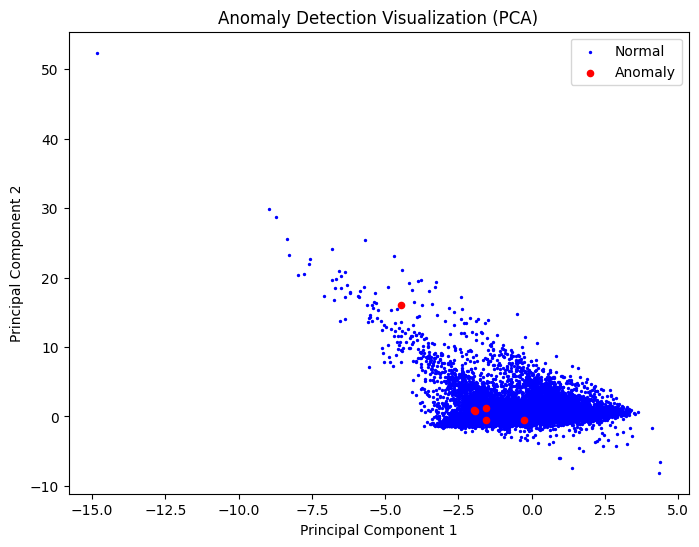

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[iso_pred==0,0],
    x_pca[iso_pred==0,1],
    c='blue',
    s=2,
    label='Normal'
)

plt.scatter(
    x_pca[iso_pred==1,0],
    x_pca[iso_pred==1,1],
    c='red',
    s=20,
    label='Anomaly'
)

plt.legend()
plt.title("Anomaly Detection Visualization (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [ ]:
#the graph will look something like this
# Normal data → dense cluster
# Anomalies → scattered points

for better understanding lets see

# **t-SNE:**

it stands for t-distributed stochastic neighbor embedding.

t-SNE tries to :

Place similar points close together
Place different points far apart

**PCA vs t-SNE**
| PCA                        | t-SNE                     |
| -------------------------- | ------------------------- |
| Linear reduction           | Non-linear reduction      |
| Fast                       | Slower                    |
| Preserves global structure | Preserves local structure |
| Good for preprocessing     | Best for visualization    |


PCA → flattening a 3D object into 2D
t-SNE → rearranging points to show clusters clearly

This is why t-SNE is popular in ML research visualization

In [ ]:
# t-SNE is computationally heavy and we have about 56k samples
# we will take subset of that data
from sklearn.manifold import TSNE

In [ ]:
sample_size = 5000

indices = np.random.choice(len(x_test_scaled), sample_size, replace=False)

x_sample = x_test_scaled[indices]
y_sample = y_test.iloc[indices]
iso_sample = iso_pred[indices]

why we did this?

because t-SNE complexity grows roughly like O(N²)

In [ ]:
# run t-SNE
tsne = TSNE(
    n_components=3,
    perplexity=30,
    random_state=42,
    n_iter=1000
)

x_tsne_3d = tsne.fit_transform(x_sample)

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

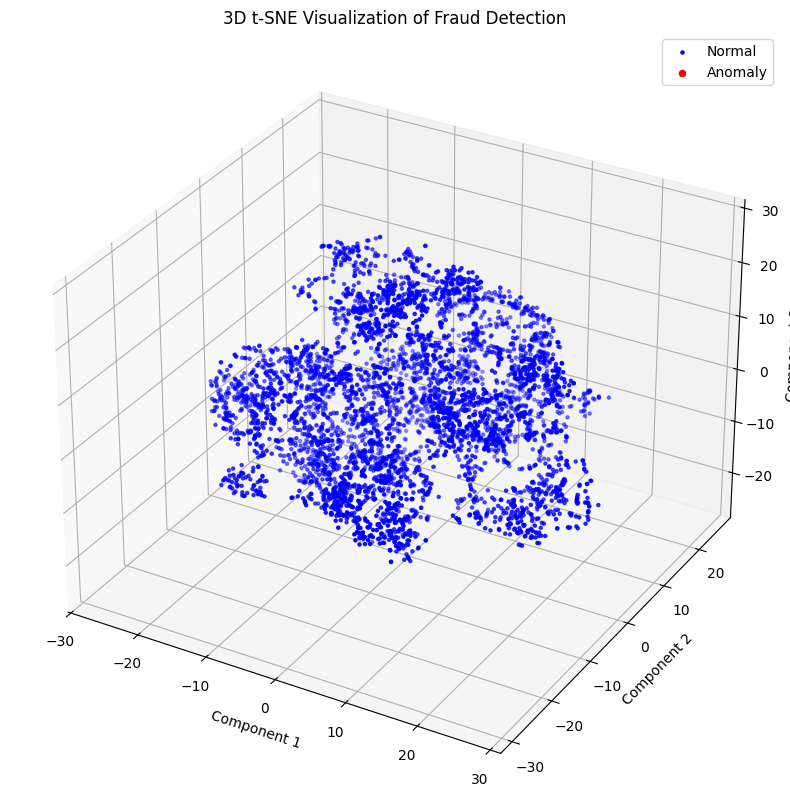

In [ ]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    x_tsne_3d[iso_sample==0,0],
    x_tsne_3d[iso_sample==0,1],
    x_tsne_3d[iso_sample==0,2],
    c='blue',
    s=5,
    label='Normal'
)

ax.scatter(
    x_tsne_3d[iso_sample==1,0],
    x_tsne_3d[iso_sample==1,1],
    x_tsne_3d[iso_sample==1,2],
    c='red',
    s=20,
    label='Anomaly'
)

ax.set_title("3D t-SNE Visualization of Fraud Detection")

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.set_zlabel("Component 3")

ax.legend()

plt.show()

# **Autoencoder for fraud detection**

we will train only on normal data.

why?

because the autoencoder should know how normal transactions behave. then when it sees fraud: Reconstruction error becomes large.

this is how the model detect anomalies.

In [ ]:
normal_train = x_trained_scaled[y_train ==0]

In [ ]:
print(normal_train.shape)

(227451, 30)


**Reconstruction error threshold**

error = original − reconstructed

But how do we decide what error is fraud?

We must define a threshold.

Common techniques =
| Method            | Idea                      |
| ----------------- | ------------------------- |
| Mean + Std        | statistical threshold     |
| Percentile        | top X% errors = anomalies |
| Validation tuning | choose best threshold     |


we will use : 95th percentile threshold

meaning : **Top 5% highest reconstruction errors = anomalies**

**Bottleneck Compression**

In anomaly detection autoencoders, we force the network to compress information heavily.

example architecture :

**30 → 16 → 8 → 4 → 8 → 16 → 30**

Because strong compression forces the model to learn core patterns of normal transactions.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

In [ ]:
# convert data to torch tensors
X_train_tensor = torch.tensor(normal_train, dtype=torch.float32)
X_test_tensor = torch.tensor(x_test_scaled, dtype=torch.float32)

In [ ]:
class Autoencoder(nn.Module):
  def __init__(self):
    super(Autoencoder, self).__init__()

    self.encoder = nn.Sequential(
        nn.Linear(30,16),
        nn.ReLU(),
        nn.Linear(16,8),
        nn.ReLU(),
        nn.Linear(8,4)
    )

    self.decoder = nn.Sequential(
        nn.Linear(4,8),
        nn.ReLU(),
        nn.Linear(8,16),
        nn.ReLU(),
        nn.Linear(16,30)
    )

  def forward(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)

    return decoded

In [ ]:
# initialize the model

model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# here we are using mini batch training

epochs = 20
batch_size = 256

for epoch in range(epochs):

    for i in range(0, len(X_train_tensor), batch_size):

        batch = X_train_tensor[i:i+batch_size]

        output = model(batch)

        loss = criterion(output, batch)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.6904844641685486
Epoch: 1 Loss: 0.6457445621490479
Epoch: 2 Loss: 0.6222039461135864
Epoch: 3 Loss: 0.5905077457427979
Epoch: 4 Loss: 0.5776775479316711
Epoch: 5 Loss: 0.5681622624397278
Epoch: 6 Loss: 0.5625116229057312
Epoch: 7 Loss: 0.5593181252479553
Epoch: 8 Loss: 0.557049572467804
Epoch: 9 Loss: 0.5528181195259094
Epoch: 10 Loss: 0.5515657663345337
Epoch: 11 Loss: 0.5489956736564636
Epoch: 12 Loss: 0.5494534373283386
Epoch: 13 Loss: 0.5485141277313232
Epoch: 14 Loss: 0.5486814975738525
Epoch: 15 Loss: 0.5504909157752991
Epoch: 16 Loss: 0.5526400208473206
Epoch: 17 Loss: 0.5540443062782288
Epoch: 18 Loss: 0.5564149022102356
Epoch: 19 Loss: 0.5581201314926147


In [ ]:
with torch.no_grad():

    reconstructed = model(X_test_tensor)

    errors = torch.mean((X_test_tensor - reconstructed)**2, dim=1)

errors = errors.numpy()

In [ ]:
# top 5% highest errors = anomaly

threshold = np.percentile(errors, 95)

In [ ]:
# predict fraud
ae_pred = (errors > threshold).astype(int)

In [ ]:
print(confusion_matrix(y_test, ae_pred))
print(classification_report(y_test, ae_pred))

[[54099  2765]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.03      0.86      0.06        98

    accuracy                           0.95     56962
   macro avg       0.51      0.90      0.52     56962
weighted avg       1.00      0.95      0.97     56962



# **Model Comparison Dashboard**

In [ ]:
#Logistic Regression
from sklearn.metrics import classification_report

log_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

In [ ]:
log_precision = log_report['1']['precision']
log_recall = log_report['1']['recall']
log_f1 = log_report['1']['f1-score']

In [ ]:
# Isolation Forest Metrics
iso_report = classification_report(
    y_test,
    iso_pred,
    output_dict=True
)

iso_precision = iso_report['1']['precision']
iso_recall = iso_report['1']['recall']
iso_f1 = iso_report['1']['f1-score']

In [ ]:
# Autoencoder metrics
ae_report = classification_report(
    y_test,
    ae_pred,
    output_dict=True
)

ae_precision = ae_report['1']['precision']
ae_recall = ae_report['1']['recall']
ae_f1 = ae_report['1']['f1-score']

In [ ]:
# lets build comparison table
comparison = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Isolation Forest",
        "Autoencoder"
    ],

    "Precision":[
        log_precision,
        iso_precision,
        ae_precision
    ],

    "Recall":[
        log_recall,
        iso_recall,
        ae_recall
    ],

    "F1 Score":[
        log_f1,
        iso_f1,
        ae_f1
    ]

})

comparison

,Model,Precision,Recall,F1 Score
0,Logistic Regression,0.058824,0.918367,0.110565
1,Isolation Forest,0.833333,0.051020,0.096154
2,Autoencoder,0.029484,0.857143,0.057007


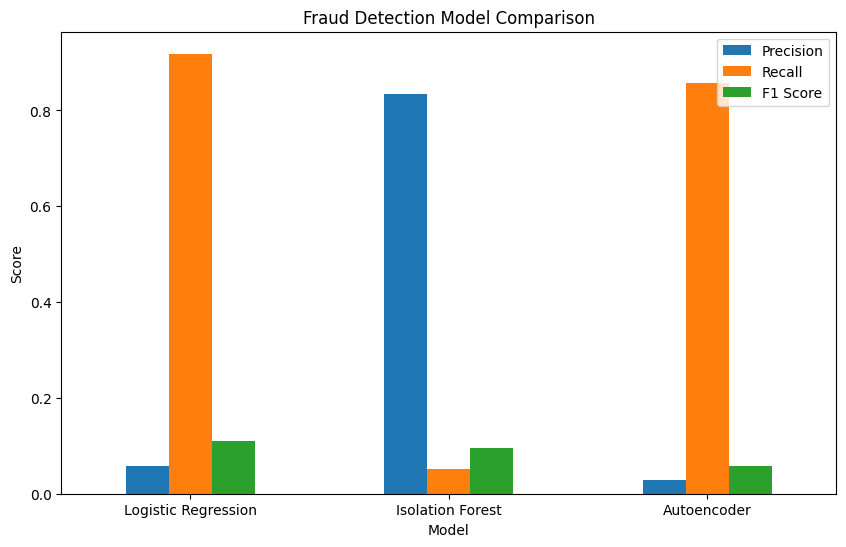

In [ ]:
# lets visualize the model performance
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Fraud Detection Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

# **Interpretation of Graph**

**Logistic Regression=**

Higher precision,
Good recall

Because it learn fraud patterns directly.

**Isolation Forest =**

Lower precision,
Lower recall

Because it only detects statistical anomalies.

**Autoencoder=**

Higher recall,
Lower precision

Because anomaly models flag more transactions as suspicious.